# Tema

## Estados Ligados

Estrategia:

-Expresar las fuerzas en coordenadas cartesianas
-Resolver dos EDOs acopladas

Ecuaciones de movimiento:

$\vec{F} = m \vec{a}$

$ \dfrac{d^2 x}{dt^2} = -\dfrac{GMx}{(x^2 + y^2)^{3/2}} $
$ \dfrac{d^2 y}{dt^2} = -\dfrac{GMy}{(x^2 + y^2)^{3/2}} $

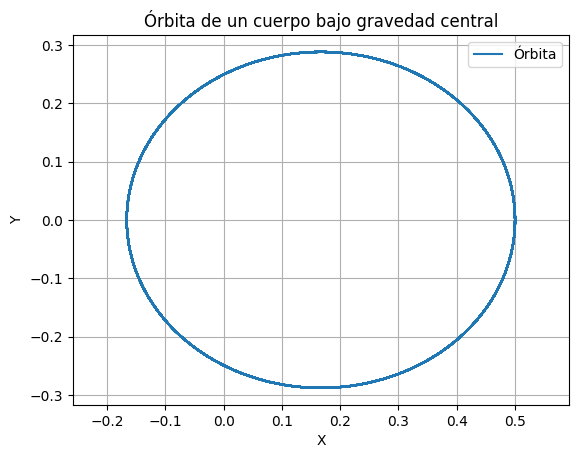

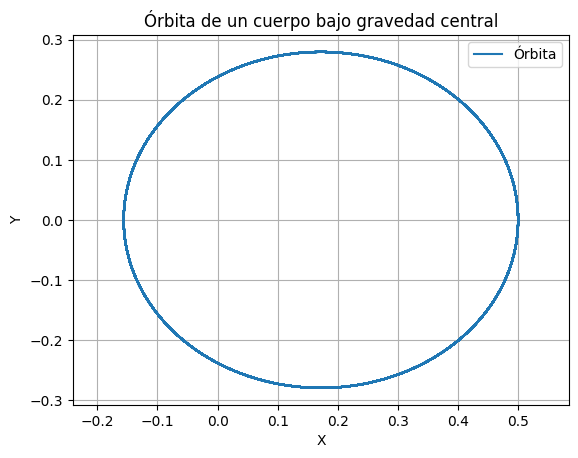

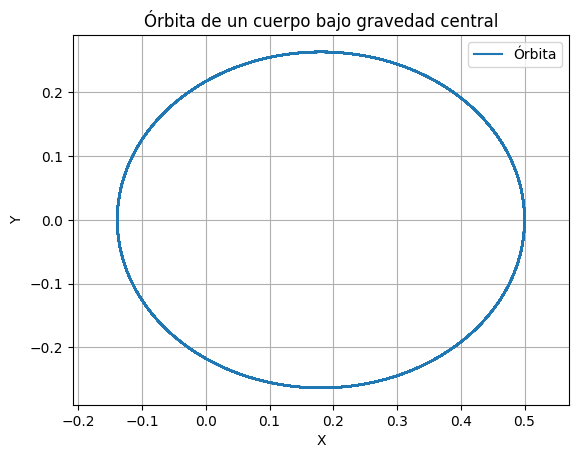

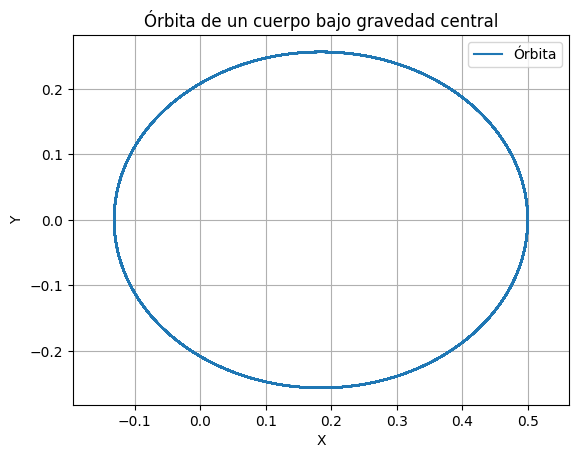

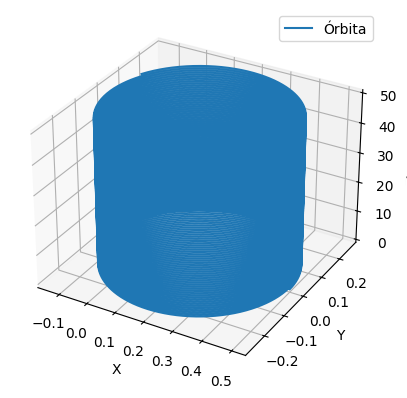

In [ ]:
# Formulación para RK4
# Vector de esttado: y_0 = x(t), y_2 = y(t), y_3 = v_x(t), y_4 = v_y(t)

import fcl1109 as fcl
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulación de órbitas
# Condiciones iniciales con GM = 1
x0 = 0.5
y0 = 0.0
vx0 = 0.0
vy0 = 1.4142 #2.2 #1.4142

# Parámetros de la simulación
t0 = 0.0
tf = 50.0
dt = 0.001
# Número de pasos
n_steps = int((tf - t0) / dt)

# Inicialización de arrays para almacenar resultados "y" general para y0,y1,y2,y3
t_values = np.zeros(n_steps)
y_values = np.zeros((n_steps, 4))  # 4 columnas para x, y, vx, vy

# Condición inicial
y_values[0] = [x0, y0, vx0, vy0]

# Función para calcular las derivadas
def derivatives(y): # Recordar que si quiero usar el rk4 de la librería fcl1109 debo añadir el tiempo a la función
    x, y, vx, vy = y
    r = np.sqrt(x**2 + y**2)
    ax = -x / r**3  # Aceleración en x
    ay = -y / r**3  # Aceleración en y
    return np.array([vx, vy, ax, ay])

# Fuerza corregida: F = (-k/r^2 + C/r^3) r_hat
def derivatives_n(k, C):
    def f(t, state):
        x, y, vx, vy = state
        r = np.sqrt(x**2 + y**2)
        ax = (-k / r**3 + C / r**4) * x
        ay = (-k / r**3 + C / r**4) * y
        return np.array([vx, vy, ax, ay])
    return f

# RK4
#for i in range(1, n_steps):
#    t = t0 + i * dt
#    t_values[i] = t
#    
#    y = y_values[i-1]
#    
#    k1 = derivatives(y)
#    k2 = derivatives(y + 0.5 * dt * k1)
#    k3 = derivatives(y + 0.5 * dt * k2)
#    k4 = derivatives(y + dt * k3)
#    
#    y_values[i] = y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# Usando rk4 de la librería fcl1109 y n general
n = [2.005, 2.1, 2.3, 2.4]
C_rel = 0.02
for j in n:
    
    t_values[0] = t0
    for i in range(1, n_steps):
        estado = y_values[i-1]
        t = t0 + i * dt
        t_values[i] = t
        y_values[i] = fcl.rk4(derivatives_n(j, C_rel), t, estado, dt)

    # Graficar la órbita 2D
    plt.figure()
    plt.plot(y_values[:, 0], y_values[:, 1], label='Órbita')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Órbita de un cuerpo bajo gravedad central')
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()

# Graficar la órbita 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(y_values[:, 0], y_values[:, 1], t_values, label='Órbita')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Tiempo')
ax.legend()
plt.show()